In [3]:
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [5]:
# scikit-learn icindeki hazir 8x8 piksellik el yazisi rakamlar veri seti
dataset = load_digits()

# X: goruntulerin piksel matrisleri - features
# y: goruntunun hangi rakam oldugu - target
X, y = dataset.data, dataset.target

print(f"Toplam ornek sayisi: {X.shape[0]}")
print(f"Her bir ornege ait ozellik (piksel) sayisi: {X.shape[1]}")

Toplam ornek sayisi: 1797
Her bir ornege ait ozellik (piksel) sayisi: 64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# veri %80 egitim, %20 dogrulama - validation - olarak ayirma
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# skorlari tutmak icin bos listeler
train_scores = []
val_scores = []
train_sizes = []

# model tanimlama
model = KNeighborsClassifier()

# for dongusu: egitime 10 veri ile basla, sona kadar 30'ar 30'ar artirarak git
for m in range(10, len(X_train), 30):
    # modeli sadece o anki 'm' adet veriyle egitme
    model.fit(X_train[:m], y_train[:m])

    # egitim basarisini olcme: ogretilen 'm' adet veriyi tekrar sorma
    y_train_predict = model.predict(X_train[:m])
    train_scores.append(accuracy_score(y_train[:m], y_train_predict))

    # dogrulama basarisini olcme: model hic gormedigi tum test verisini sorma
    y_val_predict = model.predict(X_val)
    val_scores.append(accuracy_score(y_val, y_val_predict))

    # X ekseninde gostermek icin o anki veri boyutunu kaydetme
    train_sizes.append(m)


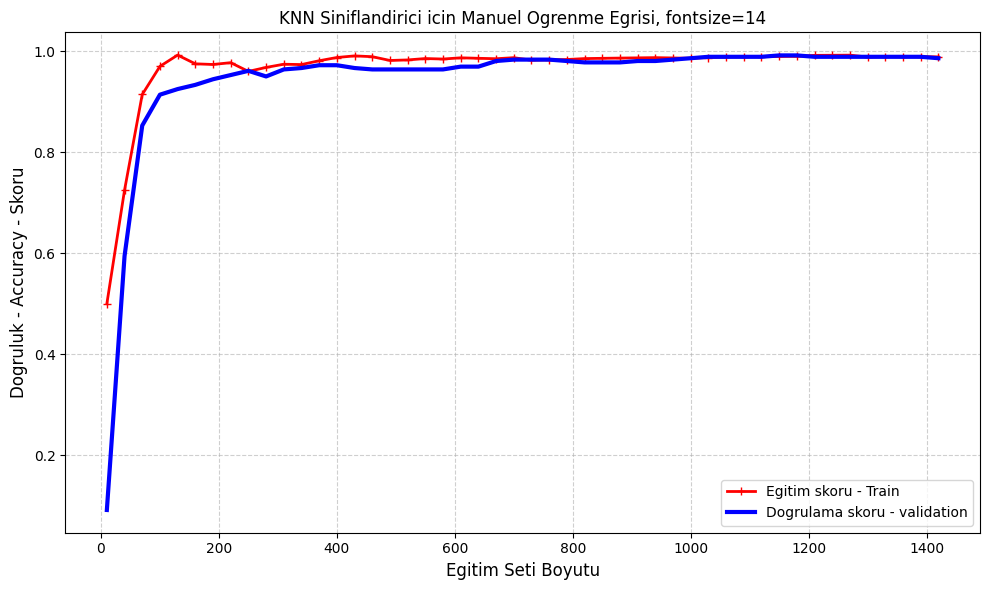

In [8]:
plt.figure(figsize=(10, 6))

# egitim skorlarinin - train - kirmizi isaretli cizgiyle cizidirlmesi
plt.plot(train_sizes, train_scores, "r-+", linewidth=2, label="Egitim skoru - Train")

# dogrulama skorlarinin - validation - kalin maviyle cizdirilmesi
plt.plot(train_sizes, val_scores, "b-", linewidth=3, label="Dogrulama skoru - validation")

plt.title("KNN Siniflandirici icin Manuel Ogrenme Egrisi, fontsize=14")
plt.xlabel("Egitim Seti Boyutu", fontsize=12)
plt.ylabel("Dogruluk - Accuracy - Skoru", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Öğrenme Eğrisi Grafiğinin Yorumlanması

Elde edilen bu grafik, modelin veri setini ne kadar sağlıklı öğrendiğini gösteren bir örnektir. Eğrilerin davranışını 3 ana başlıkta incelenebilir:

**1. Başlangıç Aşaması (0 - 200 Veri Arası):**
* Eğitim (Kırmızı) çizgisi beklendiği gibi çok yüksekten başlıyor çünkü model 10-50 arası az sayıda örneği kolaylıkla ezberleyebiliyor.
* Doğrulama (Mavi) çizgisi ise en dipten (yaklaşık 0.1 doğruluk) başlıyor. Ancak model yeni veriler görmeye başladıkça mavi çizgi inanılmaz dik bir açıyla yukarı tırmanıyor. Bu, modelin çok hızlı "öğrendiğini" ve genelleme yapma yeteneği kazandığını gösterir.

**2. Yakınsama ve Plato Aşaması (600+ Veri Sonrası):**
* Yaklaşık 600-800 eğitim verisine ulaşıldığında, her iki eğri de yataya bağlayarak bir "plato" oluşturuyor. 
* **En Kritik Nokta:** İki çizgi arasındaki o meşhur boşluk (gap) neredeyse tamamen kapanmış ve çizgiler birbirine sarılmış durumda. Üstelik birleştikleri nokta **~0.98 (%98)** gibi muazzam bir doğruluk seviyesi.

**3. Son Aşamalar:**
* **Underfitting (Yetersiz Öğrenme) YOKTUR:** Eğriler düşük bir seviyede değil, 1.0 (mükemmel) noktasına çok yakın bir zirvede buluşmuştur. Model verideki örüntüyü çok iyi yakalamıştır (Düşük Bias).
* **Overfitting (Aşırı Öğrenme) YOKTUR:** Eğitim ve Doğrulama eğrileri arasında bir uçurum kalmamıştır. Modelin ezbercilik yapmadığı, daha önce hiç görmediği test verilerinde de (mavi çizgi) eğitim verilerindeki (kırmızı çizgi) kadar yüksek başarı gösterdiği kanıtlanmıştır (Düşük Varyans).

**Karar ve Aksiyon:**
KNN (K-Nearest Neighbors) algoritması bu 8x8 piksellik rakam veri setinde hedefi tam on ikiden vurmuştur. Grafiğe bakarak rahatlıkla şu stratejik kararı verilebilir: *"Bu projede veri setini daha fazla büyütmeye veya modele daha fazla veri toplamaya gerek yoktur. Model yaklaşık 800-1000 örnekte öğrenebileceği maksimum kapasiteye çoktan ulaşmıştır."*